# 03. Random Forest — Non-linear Baseline

**Goal:** Train a Random Forest classifier and compare its performance to the 
logistic regression baseline. Evaluate whether non-linearity and feature interactions 
provide a meaningful improvement.

**Key differences from logistic regression:**
- Captures non-linear patterns and feature interactions natively
- Robust to multicollinearity → no aggressive feature de-duplication needed
- Feature importance is measured via split quality, not coefficients → no suppressor effect
- Does NOT require feature scaling

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, confusion_matrix, classification_report, roc_curve
from sklearn.model_selection import cross_val_score, StratifiedKFold

In [22]:
df = pd.read_csv('../data/raw/high_diamond_ranked_10min.csv')
print(f'Dataset frame: {df.shape}')
df.info()

Dataset frame: (9879, 40)
<class 'pandas.DataFrame'>
RangeIndex: 9879 entries, 0 to 9878
Data columns (total 40 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   gameId                        9879 non-null   int64  
 1   blueWins                      9879 non-null   int64  
 2   blueWardsPlaced               9879 non-null   int64  
 3   blueWardsDestroyed            9879 non-null   int64  
 4   blueFirstBlood                9879 non-null   int64  
 5   blueKills                     9879 non-null   int64  
 6   blueDeaths                    9879 non-null   int64  
 7   blueAssists                   9879 non-null   int64  
 8   blueEliteMonsters             9879 non-null   int64  
 9   blueDragons                   9879 non-null   int64  
 10  blueHeralds                   9879 non-null   int64  
 11  blueTowersDestroyed           9879 non-null   int64  
 12  blueTotalGold                 9879 non-null   i

In [4]:
# From 02_baseline.ipynb we'll take the same preprocessing tools: drop columns and train_test_split except scaler tool

columns_to_drop = [
    # Identifier
    'gameId',
    
    # Definitional duplicates (blue's kill = red's death)
    'redKills',      # = blueDeaths
    'redDeaths',     # = blueKills
    
    # Deterministic complement
    'redFirstBlood', # = 1 - blueFirstBlood
    
    # Linear transforms (GPM = TotalGold / 10)
    'blueGoldPerMin',
    'redGoldPerMin',
    
    # CS duplicates
    'blueCSPerMin',  # = blueTotalMinionsKilled / 10
    'redCSPerMin',
    
    # Mirror diffs (same info with sign flip)
    'redGoldDiff',        # = -blueGoldDiff
    'redExperienceDiff',  # = -blueExperienceDiff
    
    # Aggregates (keep detail, drop sum)
    'blueEliteMonsters',  # = blueDragons + blueHeralds
    'redEliteMonsters',
]

df_copy = df.copy()
df_copy = df_copy.drop(columns=columns_to_drop)
df_copy.shape

(9879, 28)

In [5]:
X = df_copy.drop(columns=['blueWins'])
y = df_copy['blueWins']

X_train, X_test, y_train, y_test = train_test_split(X,y,
                                                   test_size = 0.2,
                                                   stratify=y,
                                                   random_state=42)

print(f'x_train shape: {X_train.shape}')
print(f'x_test shape: {X_test.shape}')
print(f'Class balance in train: {y_train.value_counts(normalize=True).to_dict()}')
print(f'Class balance in test: {y_test.value_counts(normalize=True).to_dict()}')

x_train shape: (7903, 27)
x_test shape: (1976, 27)
Class balance in train: {0: 0.500949006706314, 1: 0.49905099329368596}
Class balance in test: {0: 0.5010121457489879, 1: 0.49898785425101216}


## Model Training

We start with Random Forest default hyperparameters to see the out-of-the-box performance.

**Default hyperparameters:**
- `n_estimators=100` — number of trees
- `max_depth=None` — trees grow until all leaves are pure (risk of overfitting on small datasets)
- `min_samples_split=2` — minimum samples to split an internal node
- `max_features='sqrt'` — number of features considered at each split (≈ √27 ≈ 5)
- `random_state=42` — reproducibility

In [6]:
model = RandomForestClassifier(n_estimators=100,
                               max_depth=None,
                               max_features='sqrt',
                               min_samples_split=2,
                               min_samples_leaf=1,
                               random_state=42,
                               n_jobs=-1)
model.fit(X_train, y_train)

print('Model trained.')
print(f'Number of trees: {model.n_estimators}')
print(f'Max depth of first tree: {model.estimators_[0].get_depth()}')

Model trained.
Number of trees: 100
Max depth of first tree: 24


## Model Evaluation
We evaluate the trained logistic regression on the held-out test set using multiple metrics:

- Accuracy — overall proportion of correct predictions. Good for balanced classes.
- ROC-AUC — model's ability to rank positives above negatives, threshold-independent.
- F1 score — harmonic mean of precision and recall; robust to class imbalance.
- Confusion matrix — breakdown of TP, FP, TN, FN for detailed error analysis.

In [18]:
y_pred = model.predict(X_test)

y_pred_proba = model.predict_proba(X_test)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
f1 = f1_score(y_test, y_pred)

print(f'Accuracy: {accuracy:.4f}')
print(f'ROC-AUC:  {roc_auc:.4f}')
print(f'F1 score: {f1:.4f}')

print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Blue Loses', 'Blue Wins']))

Accuracy: 0.7206
ROC-AUC:  0.8006
F1 score: 0.7189

Classification Report:
              precision    recall  f1-score   support

  Blue Loses       0.72      0.73      0.72       990
   Blue Wins       0.72      0.72      0.72       986

    accuracy                           0.72      1976
   macro avg       0.72      0.72      0.72      1976
weighted avg       0.72      0.72      0.72      1976



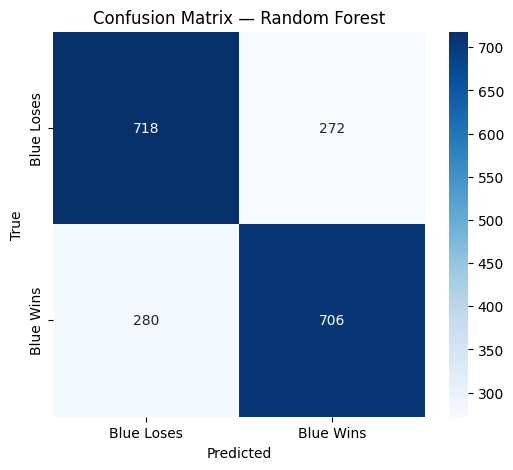

In [23]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=['Blue Loses', 'Blue Wins'],
           yticklabels=['Blue Loses', 'Blue Wins'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix — Random Forest')
plt.show()

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# ROC-AUC
cv_roc_auc = cross_val_score(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    X_train, y_train,
    cv=cv,
    scoring='roc_auc',
)

# Accuracy
cv_accuracy = cross_val_score(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    X_train, y_train,
    cv=cv,
    scoring='accuracy',)

print(f'CV ROC_AUC: {cv_roc_auc.mean():.4f} ± {cv_roc_auc.std():.4f}')
print(f'  Per-fold:  {[f"{s:.4f}" for s in cv_roc_auc]}')
print()
print(f'CV Accuracy: {cv_accuracy.mean():.4f} ± {cv_accuracy.std():.4f}')
print(f'  Per-fold:  {[f"{s:.4f}" for s in cv_accuracy]}')

CV ROC_AUC: 0.7973 ± 0.0088
  Per-fold:  ['0.8107', '0.7988', '0.7990', '0.7832', '0.7950']

CV Accuracy: 0.7225 ± 0.0106
  Per-fold:  ['0.7312', '0.7223', '0.7249', '0.7025', '0.7316']


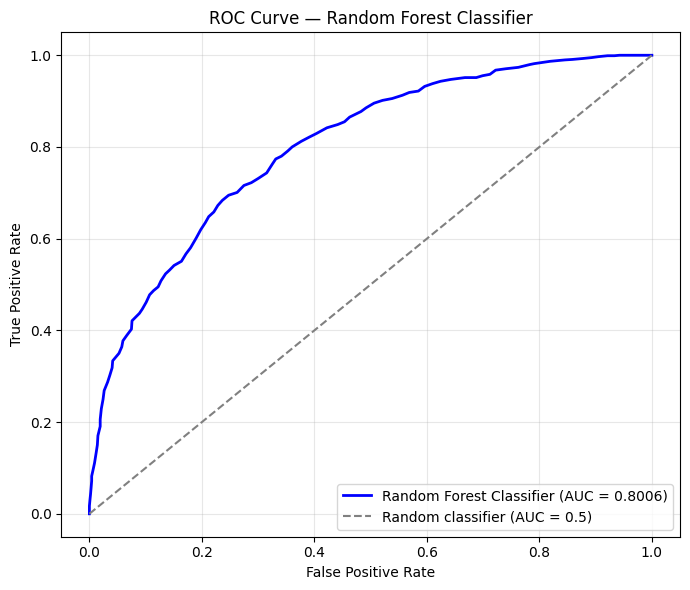

In [15]:
# Compute ROC points
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Plot
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='blue', linewidth=2, label=f'Random Forest Classifier (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random classifier (AUC = 0.5)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Random Forest Classifier')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Feature Importance

Random Forest provides feature importance via **Gini impurity decrease**: the average 
reduction in impurity across all splits that use the feature, weighted by the number of 
samples passing through those splits.

Unlike logistic regression coefficients, RF feature importance:
- Is always non-negative (there's no "direction" like positive/negative sign)
- Captures feature value through actual tree splits, not linear contribution
- Is robust to multicollinearity — correlated features share importance

In [16]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_,
}).sort_values('importance', ascending=False).reset_index(drop=True)

print('Top 10 features by importance:')
print(importance_df.head(10))

Top 10 features by importance:
                        feature  importance
0                  blueGoldDiff    0.125318
1            blueExperienceDiff    0.094265
2                 blueTotalGold    0.084877
3                  redTotalGold    0.076798
4            redTotalExperience    0.069570
5           blueTotalExperience    0.066333
6        blueTotalMinionsKilled    0.043122
7         redTotalMinionsKilled    0.042079
8  blueTotalJungleMinionsKilled    0.037374
9   redTotalJungleMinionsKilled    0.037132


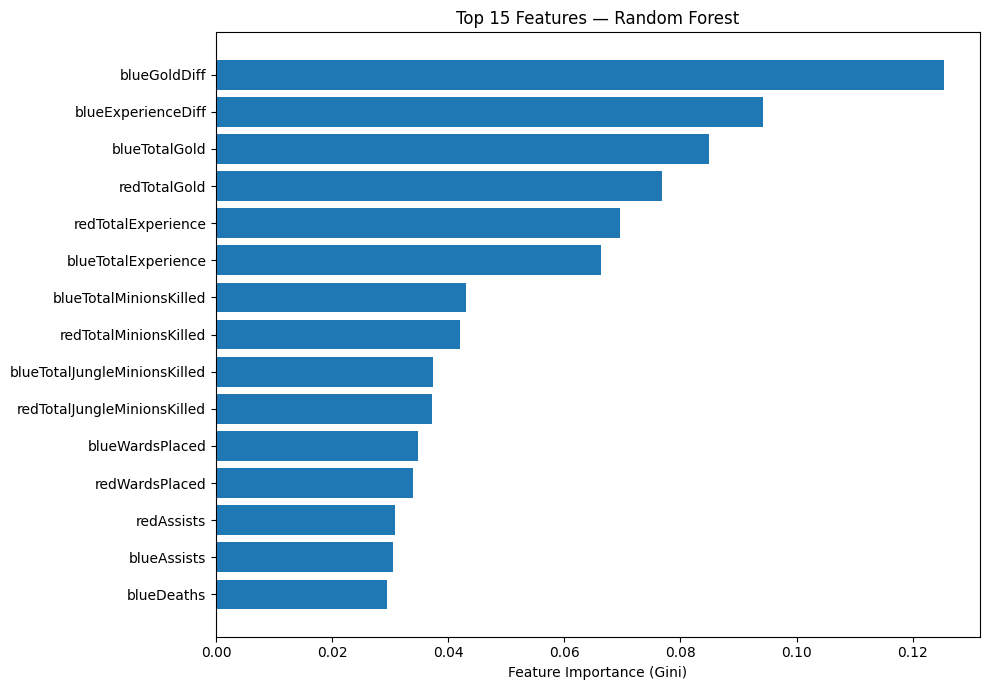

In [17]:
top_15 = importance_df.head(15)

plt.figure(figsize=(10, 7))
plt.barh(top_15['feature'][::-1], top_15['importance'][::-1])
plt.xlabel('Feature Importance (Gini)')
plt.title('Top 15 Features — Random Forest')
plt.tight_layout()
plt.show()

## Model Comparison — Logistic Regression vs Random Forest

| Metric | Logistic Regression | Random Forest | Delta |
|---|---|---|---|
| Accuracy | 0.7201 | 0.7206 | 0.0005 |
| ROC-AUC | 0.8068 | 0.8006 | -0.0062 |
| F1 | 0.7214 | 0.7189 | -0.0025 |
| CV ROC-AUC | 0.8107 ± 0.008 | 0.7973 ± 0.0088 | -0.134 |

As we can see, RF with default parameters shows itself worse than LogReg with preprocessing. In such case we need to add some tuning to RF for developing it's result.

In [19]:
# Train predictions
y_pred_train = model.predict(X_train)
y_pred_proba_train = model.predict_proba(X_train)[:, 1]

train_accuracy = accuracy_score(y_train, y_pred_train)
train_roc_auc = roc_auc_score(y_train, y_pred_proba_train)

print(f'TRAIN Accuracy: {train_accuracy:.4f}')
print(f'TRAIN ROC-AUC:  {train_roc_auc:.4f}')
print()
print(f'TEST Accuracy:  {accuracy:.4f}')
print(f'TEST ROC-AUC:   {roc_auc:.4f}')
print()
print(f'Overfitting gap (Accuracy): {train_accuracy - accuracy:.4f}')
print(f'Overfitting gap (ROC-AUC):  {train_roc_auc - roc_auc:.4f}')

TRAIN Accuracy: 1.0000
TRAIN ROC-AUC:  1.0000

TEST Accuracy:  0.7206
TEST ROC-AUC:   0.8006

Overfitting gap (Accuracy): 0.2794
Overfitting gap (ROC-AUC):  0.1994


## Diagnosis: Default RF Overfits

The default Random Forest achieves perfect training scores (Accuracy = 1.0, ROC-AUC = 1.0) 
but only 0.80 ROC-AUC on test. The 0.20 train-test gap is a textbook signature of overfitting.

**Why this happens with sklearn defaults:**
- `max_depth=None` allows trees to grow until each leaf is pure
- `min_samples_leaf=1` allows leaves containing a single sample
- On a ~8K dataset, this means trees memorize individual examples rather than learning patterns

**Bagging alone is insufficient** — each of the 100 trees overfits, and averaging their 
predictions only partially cancels noise.

**Solution:** explicitly regularize via `max_depth`, `min_samples_leaf`, and `min_samples_split`.

## Tuning: Reducing Overfitting

We retrain with regularization to prevent leaves from capturing individual training points:
- `max_depth=10` — limit tree depth
- `min_samples_leaf=20` — leaves must contain at least 20 samples
- `min_samples_split=50` — nodes need 50+ samples to be split

In [20]:
model_tuned = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=20,
    min_samples_split=50,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1,
)
model_tuned.fit(X_train, y_train)

# Predictions
y_pred_tuned = model_tuned.predict(X_test)
y_pred_proba_tuned = model_tuned.predict_proba(X_test)[:, 1]

# Train metrics
y_pred_train_tuned = model_tuned.predict(X_train)
y_pred_proba_train_tuned = model_tuned.predict_proba(X_train)[:, 1]

# Compute
train_acc_t = accuracy_score(y_train, y_pred_train_tuned)
train_auc_t = roc_auc_score(y_train, y_pred_proba_train_tuned)
test_acc_t = accuracy_score(y_test, y_pred_tuned)
test_auc_t = roc_auc_score(y_test, y_pred_proba_tuned)

print('=== Tuned RF ===')
print(f'TRAIN Accuracy: {train_acc_t:.4f}')
print(f'TRAIN ROC-AUC:  {train_auc_t:.4f}')
print(f'TEST Accuracy:  {test_acc_t:.4f}')
print(f'TEST ROC-AUC:   {test_auc_t:.4f}')
print(f'Gap ROC-AUC:    {train_auc_t - test_auc_t:.4f}')

=== Tuned RF ===
TRAIN Accuracy: 0.7757
TRAIN ROC-AUC:  0.8637
TEST Accuracy:  0.7191
TEST ROC-AUC:   0.8044
Gap ROC-AUC:    0.0593


In [21]:
cv_roc_auc_tuned = cross_val_score(
    RandomForestClassifier(
        n_estimators=200, max_depth=10, min_samples_leaf=20,
        min_samples_split=50, random_state=42, n_jobs=-1,
    ),
    X_train, y_train, cv=cv, scoring='roc_auc',
)
print(f'CV ROC-AUC (tuned): {cv_roc_auc_tuned.mean():.4f} ± {cv_roc_auc_tuned.std():.4f}')

CV ROC-AUC (tuned): 0.8066 ± 0.0089


## Model Comparison — Logistic Regression vs Random Forest

| Metric | Logistic Regression | RF Default | RF Tuned |
|---|---|---|---|
| Test Accuracy | 0.7201 | 0.7206 | 0.7191 |
| Test ROC-AUC | 0.8068 | 0.8006 | 0.8044 |
| Test F1 | 0.7214 | 0.7189 | 0.7191 |
| CV ROC-AUC | 0.8107 ± 0.008 | 0.7973 ± 0.009 | 0.8066 ± 0.009 |
| Train-Test Gap (ROC-AUC) | ~0.01 | 0.20 | 0.06 |

### Conclusions

1. **Logistic regression is a surprisingly strong baseline** for this dataset — 
   the dataset is relatively linearly separable in feature space, especially with 
   features like `blueGoldDiff` and `blueExperienceDiff` already encoding key information.

2. **Random Forest needs explicit regularization** here. Defaults overfit due to 
   small dataset size (~8K samples). After tuning, RF reaches comparable performance 
   to logistic regression but does NOT exceed it.

3. **All three models converge to ROC-AUC ≈ 0.80-0.81.** This suggests we are close 
   to the **information ceiling** of the available features. Further gains will require 
   either:
   - **Feature engineering** (e.g., diff-based features, interaction terms, position-aware 
     ward metrics)
   - **More sophisticated models** (gradient boosting with built-in regularization)
   - **More data** (more matches, more recent patches)

4. **Next step: LightGBM** — gradient boosting handles small datasets and feature 
   interactions better than Random Forest, with built-in regularization.

### Feature Importance: Random Forest vs Logistic Regression

The RF feature importance ranking confirms the suppressor effect we observed in logistic regression:
- `blueKills` and `blueDeaths` rank below top-10 in RF, with non-negative importance
- The "negative coefficient" of `blueKills` in logistic regression was an artifact of 
  multicollinearity with `blueGoldDiff` (kills convert to gold)
- RF's split-based importance is robust to this — features simply share importance 
  rather than producing contradictory signs

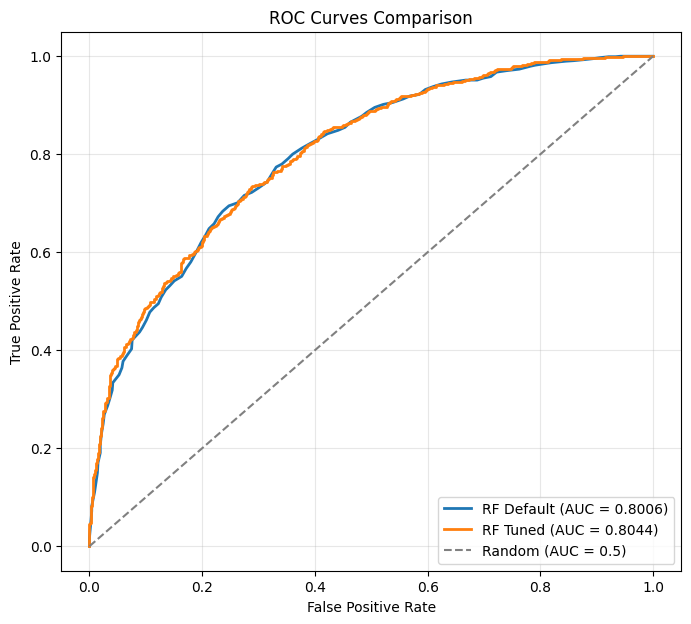

In [24]:
# Recompute proba for tuned RF (если ещё не делал)
y_pred_proba_tuned = model_tuned.predict_proba(X_test)[:, 1]

# We need to load logreg results — easiest is to retrain it here for comparison
# OR you can hardcode the values from baseline notebook

fpr_rf_default, tpr_rf_default, _ = roc_curve(y_test, y_pred_proba)  # default RF
fpr_rf_tuned, tpr_rf_tuned, _ = roc_curve(y_test, y_pred_proba_tuned)  # tuned RF

plt.figure(figsize=(8, 7))
plt.plot(fpr_rf_default, tpr_rf_default, label=f'RF Default (AUC = {roc_auc:.4f})', linewidth=2)
plt.plot(fpr_rf_tuned, tpr_rf_tuned, label=f'RF Tuned (AUC = {test_auc_t:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()